In [ ]:
!pip install rasterio

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import reproject, Resampling
from sklearn.utils import shuffle

In [ ]:
csv_path = '/content/drive/MyDrive/GEE_Exports/glacial_lake_dataset.csv'

# Dataset Generation

In [ ]:
df = pd.read_csv(csv_path)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/GEE_Exports/glacial_lake_dataset.csv'

In [ ]:
def resample_to_match(src_path, match_path):
    """
    Resample src raster (DEM) to match the grid of the 'match' raster (x_train).
    Returns a (bands, H, W) array (usually 1 band), and the matched profile.
    """
    with rasterio.open(match_path) as m:
        dst_shape = (m.height, m.width)
        dst_transform = m.transform
        dst_crs = m.crs
        dst_profile = m.profile.copy()

    with rasterio.open(src_path) as s:
        data = s.read(1)  # DEM single band
        src_transform = s.transform
        src_crs = s.crs

        out = np.empty(dst_shape, dtype=np.float32)
        reproject(
            source=data,
            destination=out,
            src_transform=src_transform,
            src_crs=src_crs,
            dst_transform=dst_transform,
            dst_crs=dst_crs,
            resampling=Resampling.bilinear
        )

    return out, dst_profile

In [ ]:
def load_xy_with_dem(x_path, y_path, dem_path):
    # Load feature raster (bands, H, W)
    with rasterio.open(x_path) as src_x:
        X = src_x.read().astype(np.float32)
        x_profile = src_x.profile
        x_transform = src_x.transform

    # Load label raster (H, W)
    with rasterio.open(y_path) as src_y:
        y = src_y.read(1)

    # Align DEM to x_grid
    dem_matched, _ = resample_to_match(dem_path, x_path)

    # Compute slope/hillshade/elevation
    slope, hillshade, elev = compute_slope_elev_hillshade(dem_matched, x_transform)

    # Stack as extra bands
    X_plus = np.vstack([
        X,
        slope[np.newaxis, ...],
        hillshade[np.newaxis, ...],
        elev[np.newaxis, ...]
    ])

    # Build feature names (base bands + DEM features)
    # If your X already includes NDWI/NDSI etc., adjust BASE_BAND_NAMES length to X.shape[0]-3
    base_n = X.shape[0]
    base_names = [f"Band_{i+1}" for i in range(base_n)]
    # Optional: try to use your preferred names if lengths match
    if len(BASE_BAND_NAMES) == base_n:
        base_names = BASE_BAND_NAMES

    feature_names = base_names + ["Slope", "Hillshade", "Elevation"]
    return X_plus, y, x_profile, feature_names

In [ ]:
print("Columns after cleaning/renaming:")
print(df.columns)

Columns after cleaning/renaming:


NameError: name 'df' is not defined

### Features & Labels

In [ ]:
### Features & Labels


In [ ]:
label_col = "label"

X shape: (2062170, 13) y shape: (2062170,)


## Train/Test

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

### Random Forest Classifier

In [ ]:
rf = RandomForestClassifier(
    n_estimators=250,
    max_depth=23,
    max_features="sqrt",
    min_samples_leaf=7,
    class_weight="balanced",
    bootstrap=True,
    criterion="gini",
    random_state=42,
    n_jobs=-1
)

In [ ]:
rf.fit(X_train, y_train)

KeyboardInterrupt: 

## Evaluation

In [ ]:
y_pred = rf.predict(X_val)
print("Accuracy:", accuracy_score(y_val, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred))
print("Classification Report:\n", classification_report(y_val, y_pred))

In [ ]:
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

[OK] Unbalanced CSV saved: /content/drive/MyDrive/GEE_Exports/glacial_lake_dataset_full_with_dem.csv (rows=2,062,170)


In [ ]:
plt.figure(figsize=(10, 6))
plt.title("Random Forest Feature Importance", fontsize=14)
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), [feature_cols[i] for i in indices], rotation=45, ha="right")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()


Per-AOI class counts:
             AOI  total_pixels   lake_1  nonlake_0 majority  \
0       barlacha          4216     3861        355  lake(1)   
1   khanchengyao         73445    70935       2510  lake(1)   
2         langpo         84976    82022       2954  lake(1)   
3   samundraTapu         17106    16715        391  lake(1)   
4         vasuki          1517     1423         94  lake(1)   
5        fanchan           594      522         72  lake(1)   
6         gepang         10575    10253        322  lake(1)   
7         karzok       1864438  1856865       7573  lake(1)   
8           beas           659      555        104  lake(1)   
9      neelkanth           743      620        123  lake(1)   
10    lamdalravi          2693     2481        212  lake(1)   
11     ravibasin          1208      985        223  lake(1)   

           ratio_lake_to_nonlake  
0       3861:355 (lake:non-lake)  
1     70935:2510 (lake:non-lake)  
2     82022:2954 (lake:non-lake)  
3      16715:391 

In [ ]:
# Print ranked importance
for idx in indices:
    print(f"{feature_cols[idx]}: {importances[idx]:.4f}")


Overall class counts (ALL AOIs): {1: 2047237, 0: 14933}
Overall ratio: 2047237:14933 (lake:non-lake)


## Save Model

In [ ]:
joblib.dump(rf, model_out)
print("✅ Model saved at:", model_out)

df = pd.read_csv(balanced_csv)
print("Balanced dataset loaded:", df.shape)

In [ ]:
feature_cols = [c for c in df.columns if c not in ["label", "AOI"]]
X = df[feature_cols].values
y = df["label"].values
aois = df["AOI"].values

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

In [ ]:
rf = RandomForestClassifier(
    n_estimators=250,
    max_depth=23,
    max_features="sqrt",
    min_samples_leaf=7,
    class_weight="balanced",  # still keep weights (in case slight imbalance remains)
    bootstrap=True,
    criterion="gini",
    random_state=42,
    n_jobs=-1
)

In [ ]:
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=23,
                       min_samples_leaf=7, n_estimators=250, n_jobs=-1,
                       random_state=42)

Training Time: 23s

In [ ]:
y_pred = rf.predict(X_val)
print("\n=== Overall Evaluation on Validation Set ===")
print("Confusion Matrix:")
print(confusion_matrix(y_val, y_pred))
print("\nClassification Report:")
print(classification_report(y_val, y_pred, digits=4))


=== Overall Evaluation on Validation Set ===
Confusion Matrix:
[[3782  698]
 [ 727 3753]]

Classification Report:
              precision    recall  f1-score   support

           0     0.8388    0.8442    0.8415      4480
           1     0.8432    0.8377    0.8404      4480

    accuracy                         0.8410      8960
   macro avg     0.8410    0.8410    0.8410      8960
weighted avg     0.8410    0.8410    0.8410      8960



In [ ]:
print("\n=== Per-AOI Evaluation (Generalization Check) ===")
for aoi in np.unique(aois):
    subset = df[df["AOI"] == aoi]
    if subset.empty:
        continue

    X_aoi = subset[feature_cols].values
    y_aoi = subset["label"].values

    y_pred_aoi = rf.predict(X_aoi)
    acc = accuracy_score(y_aoi, y_pred_aoi)

    print(f"\nAOI: {aoi}")
    print("  Accuracy:", f"{acc:.4f}")
    print("  Confusion Matrix:\n", confusion_matrix(y_aoi, y_pred_aoi))
    print("  Classification Report:\n", classification_report(y_aoi, y_pred_aoi, digits=4))


=== Per-AOI Evaluation (Generalization Check) ===

AOI: barlacha
  Accuracy: 0.8239
  Confusion Matrix:
 [[298  57]
 [ 68 287]]
  Classification Report:
               precision    recall  f1-score   support

           0     0.8142    0.8394    0.8266       355
           1     0.8343    0.8085    0.8212       355

    accuracy                         0.8239       710
   macro avg     0.8243    0.8239    0.8239       710
weighted avg     0.8243    0.8239    0.8239       710


AOI: beas
  Accuracy: 0.8798
  Confusion Matrix:
 [[92 12]
 [13 91]]
  Classification Report:
               precision    recall  f1-score   support

           0     0.8762    0.8846    0.8804       104
           1     0.8835    0.8750    0.8792       104

    accuracy                         0.8798       208
   macro avg     0.8798    0.8798    0.8798       208
weighted avg     0.8798    0.8798    0.8798       208


AOI: fanchan
  Accuracy: 0.7083
  Confusion Matrix:
 [[72  0]
 [42 30]]
  Classification Repor

In [ ]:
# ============================
# Save trained model to pickle
# ============================
import joblib

# Save the Random Forest model
model_path = "/content/drive/MyDrive/GEE_Exports/rf_glacial_lake.pkl"
joblib.dump(rf, model_path)

print(f"✅ Random Forest model saved at: {model_path}")

✅ Random Forest model saved at: /content/drive/MyDrive/GEE_Exports/rf_glacial_lake.pkl


## Visualization


In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from skimage.filters import sobel

In [ ]:
def add_dem_features(dem_path, match_profile):
    """Read DEM and derive slope, hillshade, elevation (resampled to match raster)."""
    with rasterio.open(dem_path) as dem_src:
        dem = dem_src.read(1, out_shape=(match_profile["height"], match_profile["width"]),
                           resampling=rasterio.enums.Resampling.bilinear)
        transform = match_profile["transform"]

    # Elevation

    elevation = dem

    # Slope (simple gradient magnitude approximation)
    x, y = np.gradient(dem.astype("float32"))
    slope = np.arctan(np.sqrt(x**2 + y**2)) * 180/np.pi

    # Hillshade
    az, alt = 315, 45  # sun azimuth, altitude
    x_grad, y_grad = np.gradient(dem)
    slope_rad = np.arctan(np.sqrt(x_grad**2 + y_grad**2))
    aspect = np.arctan2(-x_grad, y_grad)
    az_rad = np.deg2rad(az)
    alt_rad = np.deg2rad(alt)
    hillshade = (np.sin(alt_rad) * np.cos(slope_rad) +
                 np.cos(alt_rad) * np.sin(slope_rad) * np.cos(az_rad - aspect))
    hillshade = np.clip(hillshade, 0, 1) * 255

    return elevation, slope, hillshade

In [ ]:
def compute_indices(bands_dict):
    """Compute spectral indices."""
    green, nir, swir1 = bands_dict["green"], bands_dict["nir"], bands_dict["swir1"]

    ndwi = (green - nir) / (green + nir + 1e-6)
    ndsi = (green - swir1) / (green + swir1 + 1e-6)

    return ndwi, ndsi

In [ ]:
def predict_raster_with_dem(rf, x_tif_path, dem_tif_path, out_tif_path):
    """Predict glacial lakes using RF with Sentinel-2 + derived indices + DEM features."""

    with rasterio.open(x_tif_path) as src:
        X = src.read()
        profile = src.profile
        H, W = src.height, src.width

    # Sentinel-2 bands
    blue, green, red, nir, swir1, swir2 = X[:6]

    # Indices (same as used in training CSV)
    ndwi       = (green - nir) / (green + nir + 1e-6)
    ndsi       = (green - swir1) / (green + swir1 + 1e-6)
    mndwi      = (green - swir2) / (green + swir2 + 1e-6)
    ndwi_blue  = (blue - nir) / (blue + nir + 1e-6)

    # DEM features
    elevation, slope, hillshade = add_dem_features(dem_tif_path, profile)

    # --- Final stacked features (14 total, matching CSV) ---
    stacked = np.stack([
        blue, green, red, nir, swir1, swir2,   # 6
        ndwi, ndsi, mndwi, ndwi_blue,          # 4
        slope, hillshade, elevation,           # 3
        slope                                  # Band_14 duplicate (to match training CSV)
    ], axis=0)

    # Flatten
    X_flat = stacked.reshape(stacked.shape[0], -1).T
    mask = ~np.isnan(X_flat).any(axis=1)

    y_pred = np.zeros(X_flat.shape[0], dtype=np.uint8)
    y_pred[mask] = rf.predict(X_flat[mask])

    # Reshape back
    y_pred = y_pred.reshape(H, W)

    # Save
    profile.update(count=1, dtype="uint8")
    with rasterio.open(out_tif_path, "w", **profile) as dst:
        dst.write(y_pred, 1)

    print(f"Prediction saved to {out_tif_path}")
    return y_pred

In [ ]:
example_aoi = "lamdalravi"

In [ ]:
x_tif = f"{BASE}/{example_aoi}_x_train_enhanced.tif"
y_tif = f"{BASE}/{example_aoi}_y_train.tif"
dem_tif = f"{BASE}/DEM/{example_aoi}.tif"
pred_tif = f"{BASE}/{example_aoi}_predicted.tif"

In [ ]:
y_pred = predict_raster_with_dem(rf, x_tif, dem_tif, pred_tif)

Prediction saved to /content/drive/MyDrive/GEE_Exports/lamdalravi_predicted.tif


In [ ]:
with rasterio.open(y_tif) as src:
    y_true = src.read(1)

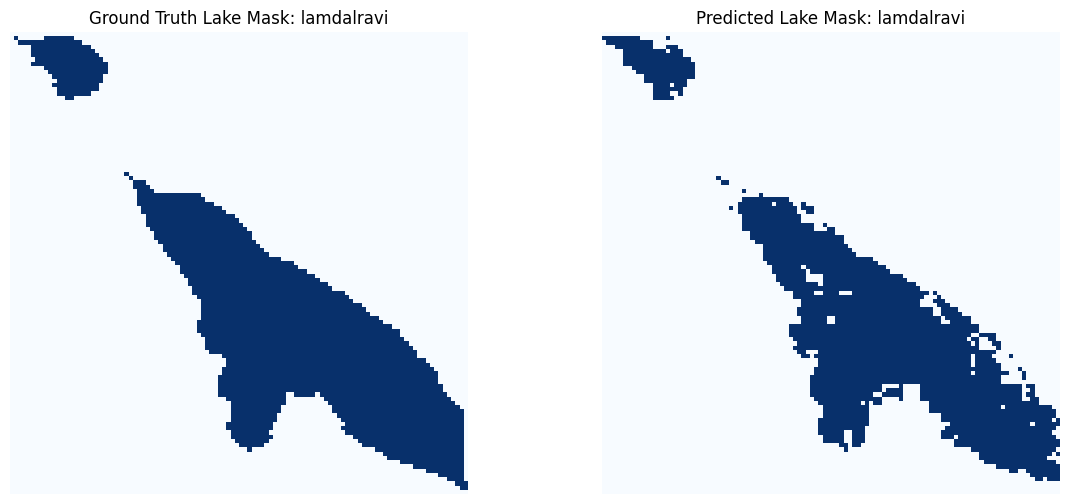

In [ ]:
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.title(f"Ground Truth Lake Mask: {example_aoi}")
plt.imshow(y_true, cmap="Blues")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title(f"Predicted Lake Mask: {example_aoi}")
plt.imshow(y_pred, cmap="Blues")
plt.axis("off")
plt.show()